In [1]:
import os
import random
import shutil

# Set paths for your dataset and a destination folder for the subset
dataset_path = '/kaggle/input/object-de/export'  # Modify to your dataset path
destination_path = '/kaggle/working/95_percent_data'  # Destination folder for 50% data

# Get all image file names from the dataset directory
image_files = [f for f in os.listdir(dataset_path) if f.endswith('.jpg')]

# Calculate 50% of the total dataset
sample_size = int(len(image_files) * 0.95)

# Randomly select 50% of the images
selected_images = random.sample(image_files, sample_size)

# Create the destination folder if it doesn't exist
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

# Copy the selected images to the destination folder
for image in selected_images:
    source = os.path.join(dataset_path, image)
    destination = os.path.join(destination_path, image)
    shutil.copy(source, destination)

print(f"Selected {len(selected_images)} images and copied them to {destination_path}")


Selected 28500 images and copied them to /kaggle/working/95_percent_data


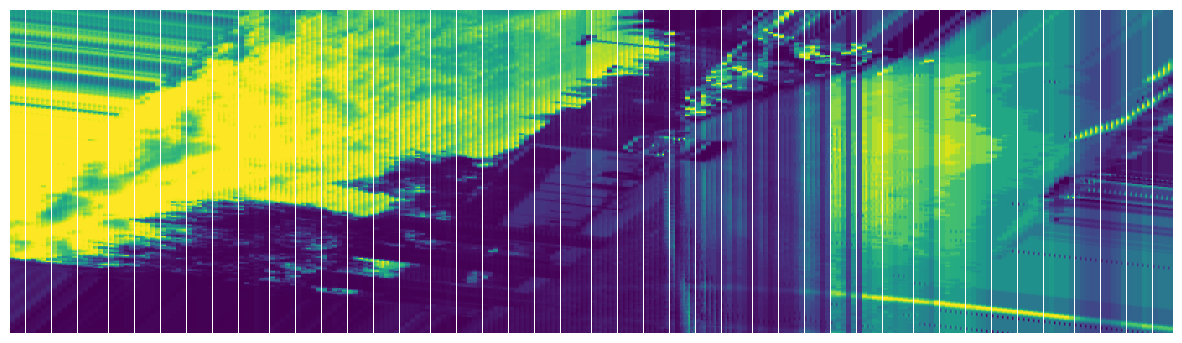

['1478898590247464166_jpg.rf.dMLtf2AgFItJkw2b8R9j.jpg', '1478896746695921606_jpg.rf.4snOe52WWgNb65dcnGs7.jpg', '1478898000105422598_jpg.rf.5a77a76ad498dfd03b9b38675f6b14c9.jpg', '1478021913084544048_jpg.rf.gUMnSClH5fKsyYHA2kIu.jpg', '1478897817292432772_jpg.rf.hflYQE0XEKQxAYTrM8kq.jpg']


In [2]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Set the path to the 50% dataset folder
dataset_path = '/kaggle/working/95_percent_data'

# Set desired image dimensions
image_size = (224, 224)  # Resize all images to 224x224 for model input

# Initialize ImageDataGenerator for image augmentation
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize the images
    rotation_range=40,  # Random rotation
    width_shift_range=0.2,  # Random width shift
    height_shift_range=0.2,  # Random height shift
    shear_range=0.2,  # Random shear
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # Fill missing pixels after transformations
)

# Load and preprocess images in batches
def load_and_preprocess_images_in_batches(dataset_path, image_size, batch_size=5):
    image_files = [f for f in os.listdir(dataset_path) if f.endswith('.jpg')]
    num_batches = len(image_files) // batch_size + 1  # Number of batches

    for batch_num in range(num_batches):
        batch_images = []
        batch_filenames = []

        # Load the images for the current batch
        for i in range(batch_num * batch_size, min((batch_num + 1) * batch_size, len(image_files))):
            filename = image_files[i]
            img_path = os.path.join(dataset_path, filename)
            img = cv2.imread(img_path)  # Read the image
            img = cv2.resize(img, image_size)  # Resize the image
            batch_images.append(img)
            batch_filenames.append(filename)

        # Convert the batch to numpy array
        batch_images = np.array(batch_images)

        # Augment the images
        for img in batch_images:
            img = np.expand_dims(img, axis=0)  # Add batch dimension
            augmented_images_gen = datagen.flow(img, batch_size=1)
            augmented_image = next(augmented_images_gen)[0].astype('float32')  # Get the augmented image
            yield augmented_image, batch_filenames  # Yield augmented image and its filenames

# Visualize some augmented images (from the first batch)
augmented_images_gen = load_and_preprocess_images_in_batches(dataset_path, image_size, batch_size=5)

# Get the first batch
augmented_images, filenames = next(augmented_images_gen)

# Determine the number of images in the batch
num_images = len(augmented_images)

# Create a subplot to visualize up to 5 images, but only plot the number of images in the batch
fig, ax = plt.subplots(1, num_images, figsize=(15, 15))

# If only one image, ax will not be a list, so we handle this case as well
if num_images == 1:
    ax = [ax]

# Display the augmented images
for i in range(num_images):
    ax[i].imshow(augmented_images[i])
    ax[i].axis('off')

plt.show()

# Print the filenames of the augmented images
print(filenames)


In [3]:
import os

# Set the path to the 50% dataset folder
dataset_path = '/kaggle/working/95_percent_data'

# Check if the dataset directory exists and contains images
if not os.path.exists(dataset_path):
    print(f"Dataset path does not exist: {dataset_path}")
else:
    images = [f for f in os.listdir(dataset_path) if f.endswith('.jpg')]
    if len(images) == 0:
        print("No images found in the dataset directory.")
    else:
        print(f"Found {len(images)} images in the dataset.")


Found 28500 images in the dataset.


In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the path to the 50% dataset folder
dataset_path = '/kaggle/working/95_percent_data'

# Set desired image dimensions
image_size = (224, 224)  # Resize all images to 224x224 for model input

# Initialize ImageDataGenerator for real-time data augmentation
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize the images
    rotation_range=40,  # Random rotation
    width_shift_range=0.2,  # Random width shift
    height_shift_range=0.2,  # Random height shift
    shear_range=0.2,  # Random shear
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # Fill missing pixels after transformations
)

# Load and preprocess images in batches (assuming single-class)
def load_and_preprocess_images(dataset_path, image_size):
    images = []
    labels = []  # Create labels for each image (here assuming a single class)
    
    # Loop through the dataset and load images
    for filename in os.listdir(dataset_path):
        if filename.endswith('.jpg'):
            img_path = os.path.join(dataset_path, filename)
            img = cv2.imread(img_path)  # Read the image
            img = cv2.resize(img, image_size)  # Resize the image
            images.append(img)
            labels.append(0)  # All images are in a single class (label = 0)
    
    # Convert images and labels to numpy arrays
    images = np.array(images)
    labels = np.array(labels)

    return images, labels

# Load the images and labels
images, labels = load_and_preprocess_images(dataset_path, image_size)

# Convert labels to one-hot encoding (even though there is only one class)
labels = tf.keras.utils.to_categorical(labels, num_classes=1)

# Split the dataset into training, validation, and testing sets (80-10-10 split)
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Augment the training data using ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow(X_train, y_train, batch_size=32)

# Build a simple CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer with sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_generator, epochs=10, validation_data=(X_val, y_val))

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the trained model (optional)
model.save('/kaggle/working/cnn_model.h5')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


713/713 ━━━━━━━━━━━━━━━━━━━━ 224s 302ms/step - accuracy: 0.9919 - loss: 0.0074 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 210s 291ms/step - accuracy: 1.0000 - loss: 9.0244e-43 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 208s 289ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 211s 293ms/step - accuracy: 1.0000 - loss: 6.9850e-37 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 209s 290ms/step - accuracy: 1.0000 - loss: 1.7117e-38 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 207s 288ms/step - accuracy: 1.0000 - loss: 7.7171e-39 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 208s 289ms/step - accuracy: 1.0000 - loss: 3.5316e-36 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
713/713 ━━━━━━━━━━━━━━━━

90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


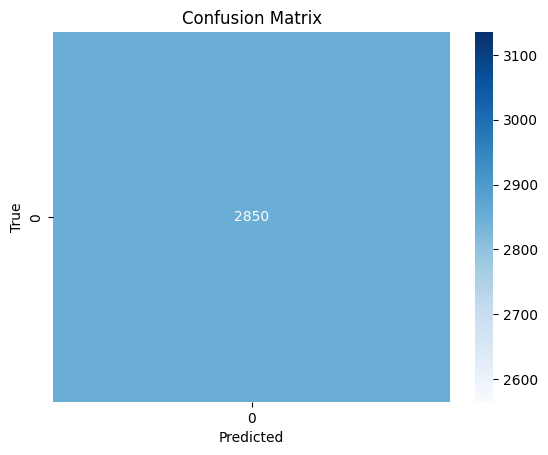

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2850

    accuracy                           1.00      2850
   macro avg       1.00      1.00      1.00      2850
weighted avg       1.00      1.00      1.00      2850



In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary class (0 or 1)

# Confusion Matrix
cm = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification report (Precision, Recall, F1-Score)
print(classification_report(y_test.argmax(axis=1), y_pred.argmax(axis=1)))


In [6]:
# Load the saved model
model = tf.keras.models.load_model('/kaggle/working/cnn_model.h5')

# Load and preprocess a new image
new_img = cv2.imread('/kaggle/input/object-de/export/1478019954685370994_jpg.rf.b2725ec9e703c9644495d02cbd07b86d.jpg')
new_img = cv2.resize(new_img, image_size)
new_img = np.expand_dims(new_img, axis=0)  # Add batch dimension
new_img = new_img / 255.0  # Normalize the image

# Predict the class
prediction = model.predict(new_img)
print("Predicted class:", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class: [[1.]]
